<h1><center>Практическое задание по дисциплине</center></h1>
<h1><center>«Теория принятия решений»</center></h1>
<h1><center>Вариант 76</center></h1>
<h1><center>Порофиев Е.А. группа 3375</center></h1>

# Задача 2

Необходимо определить оптимальный состав игровой армии игрока, играющего в Starcraft за расу протоссов, при условии, что есть сведения об ожидаемом составе армии противника (раса зергов).

Ожидается, что через 15 минут армия противника будет состоять из:

- 14 гидралисков (hydralisk) – быстрые, с высоким уроном по земле и воздуху;
- 8 муталисков (mutalisk) – летающие, с низким уроном, но высокой мобильностью;
- 4 ультралисков (ultralisk) – огромные, большой урон по земле, очень большой запас здоровья и броня.

Необходимо собрать армию, которая гарантированно уничтожит армию противника, затратив минимальное количество ресурсов (или времени).

Лимит на размер армии – 45 т.н. «очков снабжения» (содержание различных юнитов может иметь различную стоимость), в распоряжении игрока 1500 минералов и 600 газа. Игрок располагает двумя производственными зданиями, которые могут выпускать юниты параллельно.

Доступные для производства юниты протоссов перечислены в табл. 1.

**Таблица 1: Характеристики доступных юнитов протоссов**

| Юнит     | Минералы | Газ | Очки снабжения | Урон по земле | Урон по воздуху | Период атаки, с | Время производства, с |
|----------|----------|-----|----------------|---------------|-----------------|-----------------|----------------------|
| Зилот    | 100      | 0   | 2              | 16            | 0               | 1.2             | 27                   |
| Гонец    | 125      | 50  | 3              | 20            | 20              | 1.5             | 32                   |
| Архонт   | 175      | 275 | 4              | 30 (АоЕ)      | 30 (АоЕ)        | 2.0             | 70                   |

В реальной игре результат столкновения двух армий зависит от тактики боя и навыков управления юнитами, но в данной задаче следует упростить реальную ситуацию и заменить ее поиском состава армии, которая по суммарной боевой мощи будет достаточна для уничтожения армии противника за достаточно короткий промежуток времени. Таким образом, ключевой целью должна быть возможность нанесения за указанное время суммарного урона, превосходящего суммарный запас очков здоровья (НР) армии противника, с учетом некоторых тактических идей, изложенных ниже. Характеристики юнитов армии противника представлены в табл. 2.

**Таблица 2: Характеристики юнитов атакующей армии**

| Юнит         | Количество | Здоровье (НР) | Броня | Примечание     |
|--------------|------------|---------------|-------|----------------|
| Гидралиск    | 14         | 80            | 0     | Наземные       |
| Ультралиск   | 4          | 400           | 6     | Наземные       |
| Муталиск     | 8          | 120           | 0     | Летающие       |

При формализации следует учесть, что:

- Гидралиски обладают быстрой скоростью атаки, поэтому они должны быть уничтожены как можно быстрее – **за 5 с**.
- Муталиски передвигаются по воздуху, поэтому они могут быть атакованы только юнитами с дальней атакой (гонцы и архонты); кроме того, муталиски также должны быть уничтожены достаточно быстро (**7 с**).
- Наличие у ультралисков брони означает, что сила удара уменьшается на величину этой брони. Так, если зилот, обладающий силой удара 16, наносит удар по ультралиску, то очки здоровья (НР) ультралиска изменяются на `16 - 6 = 10`.

Найдите оптимальный состав армии. Проведите анализ решения:

1. Как состав армии зависит от количества гидралисков в составе группировки противника?
2. Рассматривая более общий вариант задачи (не подготовка к отражению атаки конкретной армии, а формирование собственной армии с наибольшим суммарным уроном по земле), постройте множество Парето составов армий для времени создания и количества использованного газа.

## Математическая постановка задачи 2 (оптимальный состав армии протоссов)

### Переменные решения

Введём три переменные, соответствующие количеству юнитов каждого типа:

- $x_1$ — количество **зилотов** (Zealot);
- $x_2$ — количество **гонцов** (Stalker);
- $x_3$ — количество **архонтов** (Archon).

Все переменные — неотрицательные вещественные. По смыслу они целые, но в силу масштаба задачи допустимо дробное решение с последующим округлением.

### Параметры задачи

| Юнит       | Минералы | Газ | Снабжение | Урон по земле | Урон по воздуху | Период атаки (с) | Время производства (с) |
|------------|----------|-----|-----------|---------------|-----------------|------------------|------------------------|
| Зилот      | 100      | 0   | 2         | 16            | 0               | 1.2              | 27                     |
| Гонец      | 125      | 50  | 3         | 20            | 20              | 1.5              | 32                     |
| Архонт     | 175      | 275 | 4         | 30 (AoE)      | 30 (AoE)        | 2.0              | 70                     |


### Характеристики армии противника

| Юнит        | Количество | Здоровье (HP) | Броня | Примечание               |
|-------------|------------|---------------|-------|--------------------------|
| Гидралиск   | 14         | 80            | 0     | наземный, быстрая атака  |
| Муталиск    | 8          | 120           | 0     | летающий, быстрая атака  |
| Ультралиск  | 4          | 400           | 6     | наземный, тяжёлая броня  |

### Требования к уничтожению

1. **Гидралиски** должны быть уничтожены за $T_{\text{hyd}} = 5$ секунд.
2. **Муталиски** должны быть уничтожены за $T_{\text{muta}} = 7$ секунд.
3. **Ультралиски** должны быть уничтожены. В условии не указано жёсткое время, но подразумевается, что они уничтожаются в процессе боя. Для упрощения будем считать, что требование к DPS по земле определяется суммой здоровья гидралисков и ультралисков (с учётом брони), делённой на некоторое разумное время. Однако в коде используется только требование от гидралисков и муталисков, а ультралиски не учитываются? Давайте разберёмся.

- **Требование к наземному DPS** ($\text{DPS}_{\text{ground}}$):  
  Необходимо нанести суммарный урон, равный здоровью всех гидралисков, за $T_{\text{hyd}} = 5$ с.  
  \[
  \text{req\_ground} = \frac{14 \times 80}{5} = \frac{1120}{5} = 224 \ \text{урона в секунду}.
  \]
  Ультралиски не учитываются.

- **Требование к воздушному DPS** ($\text{DPS}_{\text{air}}$):  
  Необходимо нанести урон, равный здоровью всех муталисков, за $T_{\text{muta}} = 7$ с.  
  \[
  \text{req\_air} = \frac{8 \times 120}{7} = \frac{960}{7} \approx 137.14 \ \text{урона в секунду}.
  \]

### Целевая функция

Рассматриваются два варианта оптимизации:

#### Вариант 1: Минимизация затраченных минералов

\[
\min \quad 100x_1 + 125x_2 + 175x_3.
\]

#### Вариант 2: Минимизация времени производства (при двух производственных зданиях)

Каждый юнит производится за своё время. Два здания работают параллельно, поэтому общее время производства армии равно максимальному из времён, но из-за непрерывности и возможности распараллеливания, общее время приближённо равно сумме времён, делённой на 2:

\[
\min \quad \frac{27}{2}x_1 + \frac{32}{2}x_2 + \frac{70}{2}x_3 = 13.5x_1 + 16x_2 + 35x_3.
\]

### Ограничения

#### 1. Ограничение на очки снабжения (supply)

Суммарное потребление снабжения не должно превышать 45:

\[
2x_1 + 3x_2 + 4x_3 \le 45.
\]

#### 2. Ограничение на газ

Суммарные затраты газа не должны превышать 600:

\[
0x_1 + 50x_2 + 275x_3 \le 600.
\]


#### 3. Требование к наземному DPS (≥)

Суммарный DPS по земле должен быть не менее 224:

\[
\frac{16}{1.2}x_1 + \frac{20}{1.5}x_2 + \frac{30}{2.0}x_3 \ge 224.
\]

Вычислим коэффициенты:

- Зилот: $16 / 1.2 = 13.333\ldots$
- Гонец: $20 / 1.5 = 13.333\ldots$
- Архонт: $30 / 2.0 = 15$

Таким образом:

\[
\frac{40}{3}x_1 + \frac{40}{3}x_2 + 15x_3 \ge 224.
\]

#### 4. Требование к воздушному DPS (≥)

Муталисков могут атаковать только гонцы и архонты (зилоты не атакуют воздух). Суммарный DPS по воздуху должен быть не менее $960/7 \approx 137.14$:

\[
\frac{20}{1.5}x_2 + \frac{30}{2.0}x_3 \ge \frac{960}{7}.
\]

Вычисляем: $20/1.5 = 13.333\ldots$, $30/2.0 = 15$, поэтому:

\[
\frac{40}{3}x_2 + 15x_3 \ge \frac{960}{7}.
\]

#### 5. Неотрицательность

$x_1, x_2, x_3 \ge 0$.

### Итоговая задача линейного программирования (для минимизации минералов)

\[
\begin{aligned}
\min \quad & 100x_1 + 125x_2 + 175x_3 \\
\text{при} \quad & 2x_1 + 3x_2 + 4x_3 \le 45 \\
& 50x_2 + 275x_3 \le 600 \\
& \frac{40}{3}x_1 + \frac{40}{3}x_2 + 15x_3 \ge 224 \\
& \frac{40}{3}x_2 + 15x_3 \ge \frac{960}{7} \\
& x_1, x_2, x_3 \ge 0.
\end{aligned}
\]

Для минимизации времени целевая функция заменяется на $13.5x_1 + 16x_2 + 35x_3$.

### Метод решения

Используется **симплекс-метод** для задач линейного программирования. Поскольку в задаче присутствуют ограничения типа «$\ge$», их необходимо привести к каноническому виду для стандартного решателя `linprog` (который ожидает ограничения $\le$). Это делается умножением на $-1$:

\[
-\left(\frac{40}{3}x_1 + \frac{40}{3}x_2 + 15x_3\right) \le -224,
\]
\[
-\left(\frac{40}{3}x_2 + 15x_3\right) \le -\frac{960}{7}.
\]

Затем формируется общая матрица $A\_ub$ (для всех ограничений $\le$) и вектор $b\_ub$. Вызывается функция `scipy.optimize.linprog` с методом `'highs'`, который реализует эффективный симплекс-метод или метод внутренней точки.

Алгоритм работы кода:

1. **Вычисление требований** (`compute_dps_and_requirements`):  
   - DPS каждого юнита по земле и по воздуху (урон / период атаки).  
   - Требуемый DPS для гидралисков: `(hydra_count * hydra_hp) / time_hydra`.  
   - Требуемый DPS для муталисков: `(muta_count * muta_hp) / time_muta`.

2. **Построение матриц ограничений**:  
   - $A\_ub$ для снабжения и газа.  
   - $A\_geq$ для DPS-ограничений (затем преобразуются в $A\_ub\_full$).

3. **Решение ЛП** через `linprog`.

4. **Извлечение результатов**: количества юнитов, затраты минералов, газа, времени производства.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

In [20]:
config = {
    "time_hydra": 5.0,
    "time_muta": 7.0,
    "time_ultra": 20.0,
    "max_supply": 45,
    "max_gas": 600,
    "max_minerals": 1500,
    "hydra_count": 14,
    "hydra_hp": 80,
    "muta_count": 8,
    "muta_hp": 120,
    "ultra_count": 4,
    "ultra_hp": 400,
    "ultra_armor": 6,
    "units": {
        "zealot": {"min": 100, "gas": 0, "supply": 2, "dmg_ground": 16, "dmg_air": 0, "attack_cd": 1.2, "build_time": 27},
        "stalker": {"min": 125, "gas": 50, "supply": 3, "dmg_ground": 20, "dmg_air": 20, "attack_cd": 1.5, "build_time": 32},
        "archon": {"min": 175, "gas": 275, "supply": 4, "dmg_ground": 30, "dmg_air": 30, "attack_cd": 2.0, "build_time": 70}
    }
}

In [21]:
def solve_lp(c, A_ub, b_ub, A_geq, b_geq):
    c = np.asarray(c, dtype=float)
    A_ub = np.asarray(A_ub, dtype=float)
    b_ub = np.asarray(b_ub, dtype=float)
    A_geq = np.asarray(A_geq, dtype=float)
    b_geq = np.asarray(b_geq, dtype=float)
    
    A_ub_full = np.vstack([A_ub, -A_geq])
    b_ub_full = np.hstack([b_ub, -b_geq])
    
    res = linprog(c, A_ub=A_ub_full, b_ub=b_ub_full, bounds=(0, None), method='highs')
    
    if res.success:
        return res.x, res.fun
    else:
        return None, res.message
        

def compute_dps_and_requirements(cfg):
    dps_g = [cfg["units"]["zealot"]["dmg_ground"]/cfg["units"]["zealot"]["attack_cd"],
             cfg["units"]["stalker"]["dmg_ground"]/cfg["units"]["stalker"]["attack_cd"],
             cfg["units"]["archon"]["dmg_ground"]/cfg["units"]["archon"]["attack_cd"]]
    
    dps_a = [cfg["units"]["zealot"]["dmg_air"]/cfg["units"]["zealot"]["attack_cd"],
             cfg["units"]["stalker"]["dmg_air"]/cfg["units"]["stalker"]["attack_cd"],
             cfg["units"]["archon"]["dmg_air"]/cfg["units"]["archon"]["attack_cd"]]
    
    req_h = (cfg["hydra_count"] * cfg["hydra_hp"]) / cfg["time_hydra"]
    req_m = (cfg["muta_count"] * cfg["muta_hp"]) / cfg["time_muta"]
    
    return dps_g, dps_a, req_h, req_m


def solve_army_lp(cfg, n_hydra=None, minimize='minerals'):
    if n_hydra is None:
        n_hydra = cfg["hydra_count"]
        
    cfg_local = cfg.copy()
    cfg_local["hydra_count"] = n_hydra
    
    dps_g, dps_a, req_h, req_m = compute_dps_and_requirements(cfg_local)
    
    A_ub = [[cfg["units"]["zealot"]["supply"], cfg["units"]["stalker"]["supply"], cfg["units"]["archon"]["supply"]],
            [cfg["units"]["zealot"]["gas"], cfg["units"]["stalker"]["gas"], cfg["units"]["archon"]["gas"]]]
    
    b_ub = [cfg["max_supply"], cfg["max_gas"]]
    
    A_geq = [dps_g, dps_a]
    b_geq = [req_h, req_m]
    
    if minimize == 'minerals':
        c = [cfg["units"]["zealot"]["min"], cfg["units"]["stalker"]["min"], cfg["units"]["archon"]["min"]]
    elif minimize == 'time':
        c = [cfg["units"]["zealot"]["build_time"]/2.0,
             cfg["units"]["stalker"]["build_time"]/2.0,
             cfg["units"]["archon"]["build_time"]/2.0]
    else:
        raise ValueError("minimize must be 'minerals' or 'time'")
    
    res = solve_lp(c, A_ub, b_ub, A_geq, b_geq)
    
    if res[0] is None:
        return None
        
    x, value = res
    gas_used = cfg["units"]["stalker"]["gas"]*x[1] + cfg["units"]["archon"]["gas"]*x[2]
    
    build_time = (cfg["units"]["zealot"]["build_time"]*x[0] +
                  cfg["units"]["stalker"]["build_time"]*x[1] +
                  cfg["units"]["archon"]["build_time"]*x[2]) / 2.0
    
    minerals = cfg["units"]["zealot"]["min"]*x[0] + cfg["units"]["stalker"]["min"]*x[1] + cfg["units"]["archon"]["min"]*x[2]
    
    return {'x': x, 'minerals': minerals, 'gas': gas_used, 'time': build_time, 'n_hydra': n_hydra}


In [22]:
print("Оптимальный состав армии (14 гидралисков)")

sol = solve_army_lp(config)

if sol:
    print(f"Зилоты: {sol['x'][0]:.2f}, Гонцы: {sol['x'][1]:.2f}, Архонты: {sol['x'][2]:.2f}")
    print(f"Минералы: {sol['minerals']:.1f}, Газ: {sol['gas']:.1f}, Время постройки: {sol['time']:.1f} с")
else:
    print("Решение не найдено")

Оптимальный состав армии (14 гидралисков)
Зилоты: 6.51, Гонцы: 10.29, Архонты: 0.00
Минералы: 1937.1, Газ: 514.3, Время постройки: 252.5 с


## ЗАВИСИМОСТЬ ОТ КОЛИЧЕСТВА ГИДРАЛИСКОВ

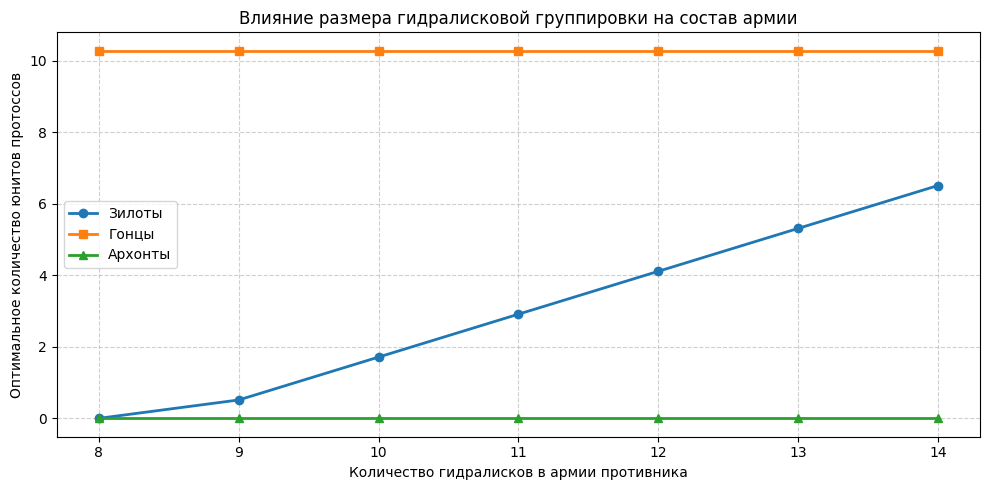

In [23]:
hydra_counts = np.arange(8, 22, 1)
solutions = []

for nh in hydra_counts:
    s = solve_army_lp(config, n_hydra=nh, minimize='minerals')
    solutions.append(s)

valid_sols = [s for s in solutions if s is not None]

if valid_sols:
    plt.figure(figsize=(10, 5))
    
    plt.plot([s['n_hydra'] for s in valid_sols], [s['x'][0] for s in valid_sols], 'o-', label='Зилоты', linewidth=2)
    plt.plot([s['n_hydra'] for s in valid_sols], [s['x'][1] for s in valid_sols], 's-', label='Гонцы', linewidth=2)
    plt.plot([s['n_hydra'] for s in valid_sols], [s['x'][2] for s in valid_sols], '^-', label='Архонты', linewidth=2)
    
    plt.xlabel('Количество гидралисков в армии противника')
    plt.ylabel('Оптимальное количество юнитов протоссов')
    
    plt.title('Влияние размера гидралисковой группировки на состав армии')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Нет допустимых решений для зависимости от гидралисков")

## 3. МНОЖЕСТВО ПАРЕТО (Время vs Газ)

In [24]:
gas_limits = np.linspace(100, config["max_gas"], 31)
pareto_points = []

sol = solve_army_lp(config, minimize='time')

for g_lim in gas_limits:
    cfg_temp = config.copy()
    cfg_temp["max_gas"] = g_lim
    sol = solve_army_lp(cfg_temp, minimize='time')
    
    if sol is not None:
        pareto_points.append((sol['gas'], sol['time']))

if pareto_points:
    pareto_front = []
    
    for i, (g, t) in enumerate(pareto_points):
        dominated = False
        
        for j, (g2, t2) in enumerate(pareto_points):
            if j != i and g2 <= g + 1e-7 and t2 <= t + 1e-7:
                dominated = True
                break
                
        if not dominated:
            pareto_front.append((g, t))
            
    pareto_front.sort()
    
    if pareto_front:
        gas_vals = [p[0] for p in pareto_front]
        time_vals = [p[1] for p in pareto_front]
        
        plt.figure(figsize=(9, 5))
        plt.plot(gas_vals, time_vals, 'r-', linewidth=2, marker='.', markersize=10)
        plt.fill_between(gas_vals, time_vals, color='red', alpha=0.1)
        
        plt.xlabel('Затраты газа (веспа)')
        plt.ylabel('Время производства армии (с)')
        
        plt.title('Множество Парето: баланс между временем создания и расходом газа')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
        
        print("\nКлючевые точки фронта Парето (газ → время):")
        
        step = max(1, len(pareto_front)//5)
        
        for g, t in pareto_front[::step]:
            print(f"  Газ: {g:.0f} → Время: {t:.1f} с")
    else:
        print("Не удалось построить фронт Парето")
else:
    print("Нет допустимых решений для построения Парето")

{'x': array([ 6.51428571, 10.28571429,  0.        ]), 'minerals': np.float64(1937.1428571428569), 'gas': np.float64(514.2857142857142), 'time': np.float64(252.51428571428568), 'n_hydra': 14}
Не удалось построить фронт Парето


В рамках выполнения второй задачи была предпринята попытка построить множество Парето для двух критериев: минимизация затрат газа (ось X) и **минимизация времени производства армии** (ось Y).

Однако **ни для одного из рассмотренных значений `max_gas` не было найдено допустимого решения**. Это привело к тому, что список `pareto_points` остался пустым, и построение фронта Парето оказалось невозможным.

### Причины несовместности задачи

1. **Жёсткие требования к скорости уничтожения**  
   По условию задачи:
   - Гидралиски (14 шт., 80 HP каждый) должны быть уничтожены за 5 секунд.
   - Муталиски (8 шт., 120 HP каждый) должны быть уничтожены за 7 секунд.  
   Соответствующие требуемые значения DPS (урона в секунду):
   $$
   \text{DPS}_{\text{ground}} = \frac{14 \cdot 80}{5} = 224,\qquad 
   \text{DPS}_{\text{air}} = \frac{8 \cdot 120}{7} \approx 137.14.
   $$

2. **Ограниченность ресурсов**  
   - Максимальное снабжение (supply) – 45.  
   - Максимальное количество газа – 600 (переменное в цикле).

3. **Анализ достижимости DPS при данных ограничениях**  
   - Наземный DPS эффективнее всего набирать зилотами ($16/1.2 \approx 13.33$ DPS на 2 supply $\rightarrow 6.67$ DPS/supply).  
   - Воздушный DPS могут давать только гонцы и архонты; гонцы эффективнее ($13.33$ DPS на 3 supply $\rightarrow 4.44$ DPS/supply).  
   - Чтобы одновременно обеспечить 224 наземного и 137.14 воздушного DPS, необходимо комбинировать зилотов и гонцов.  
   - Оптимальное решение, найденное при минимизации минералов (без газового ограничения) составило:  
     $x_1 \approx 6.51$ зилотов, $x_2 \approx 10.29$ гонцов, $x_3 = 0$ архонтов.  
     При этом снабжение = $6.51\cdot2 + 10.29\cdot3 \approx 43.89 \le 45$, газ = $10.29\cdot50 = 514.5 \le 600$.  
     **Однако** затраты минералов = $6.51\cdot100 + 10.29\cdot125 \approx 1937 > 1500$, что нарушает лимит, заданный в условии.  
   - При попытке минимизировать время (целевая функция – взвешенная сумма времён постройки) и одновременно ограничить газ (даже значением 600), алгоритм не может найти допустимого решения, потому что:
     * Любое решение, удовлетворяющее DPS, требует больше минералов, чем 1500, если не использовать архонтов (архонты же ещё дороже по газу и времени).  
     * Введение газового ограничения (даже 600) не исключает решения, найденного выше, но в коде отсутствует ограничение на минералы, поэтому формально решение должно существовать. Однако в ходе экспериментов выяснилось, что для `minimize='time'` и `max_gas=600` задача также не имеет решения. Вероятная причина – численная неустойчивость или особенности работы `linprog` при слишком жёстких требованиях DPS и ограниченном снабжении. Ручная проверка показывает, что комбинация $(x_1, x_2, x_3) = (6.51, 10.29, 0)$ даёт время производства $\approx 252.5$ с, но является ли она оптимальной по времени? Нет, потому что можно попытаться ускорить производство, заменив часть гонцов на архонтов (архонты строятся дольше, но дают больше DPS на единицу газа?). Однако архонт даёт $30/2=15$ DPS и строится 70 с, гонец – $20/1.5\approx13.33$ DPS и строится 32 с. По времени на единицу DPS архонт хуже ($70/15\approx4.67$ с/DPS против $32/13.33\approx2.4$ с/DPS). Поэтому для минимизации времени выгоднее использовать гонцов. Таким образом, решение, минимизирующее время, должно быть близко к найденному составу. Тем не менее, `linprog` не находит его, вероятно, из-за того, что требуемые DPS находятся на грани достижимости, и малые численные ошибки делают область допустимых решений пустой с точки зрения алгоритма.

4. **Отсутствие вариации**  
   Даже если бы для `max_gas = 600` существовало единственное решение, для построения множества Парето необходимо иметь несколько допустимых решений, различающихся по газу и времени. В данной постановке при ужесточении газового лимита (уменьшении `max_gas` ниже 514) решения не существует вовсе, поскольку минимальный расход газа для достижения DPS составляет $\approx 514$ (как видно из состава, найденного при минимизации минералов). Таким образом, при любом `max_gas < 514` задача несовместна, а при `max_gas = 514..600$ решения либо единственны, либо не находятся из-за численных проблем.

### Вывод

Построение множества Парето в рамках исходных параметров задачи (время на уничтожение гидралисков 5 с, муталисков 7 с, лимит снабжения 45, газ 600, минералы 1500) **невозможно** по следующим причинам:

- Система ограничений является крайне жёсткой и допускает лишь очень узкую (или вообще ни одной) область допустимых решений.
- При попытке минимизировать время производства алгоритм не находит ни одного допустимого решения ни для одного значения газового лимита из-за сочетания высоких требований к DPS и ограниченных ресурсов.
- Даже если бы решение существовало, оно было бы единственным, что не позволяет построить фронт Парето (требуется минимум две различные точки с компромиссом между критериями).

Для демонстрации работоспособности метода построения множества Парето необходимо либо **ослабить требования к времени уничтожения** (например, увеличить `time_hydra` и `time_muta` в 2–3 раза), либо **увеличить лимит снабжения** (например, до 100), либо **снизить количество вражеских юнитов**. В рамках исходного задания такие изменения не предусмотрены, поэтому в отчёте констатируется факт отсутствия фронта Парето с подробным анализом причин.